In [1]:
import sys; sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.calibration import calibration_curve

df = pd.read_csv("../data/processed/credit_default_features.csv")
y = df["default"]
X = df.drop(columns=["default"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

lgbm = joblib.load("../src/lgbm_model.joblib")
proba = lgbm.predict_proba(X_test)[:, 1]
preds_default_threshold = (proba >= 0.5).astype(int)

In [2]:
def group_fairness_report(X_test, y_test, proba, preds, group_col):
    rows = []
    groups = X_test[group_col].unique()
    for g in sorted(groups):
        mask = X_test[group_col] == g
        y_g = y_test[mask]
        proba_g = proba[mask]
        preds_g = preds[mask]

        cm = confusion_matrix(y_g, preds_g, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        tpr_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        auc = roc_auc_score(y_g, proba_g) if y_g.nunique() > 1 else np.nan

        rows.append({
            "group": g,
            "n": mask.sum(),
            "actual_default_rate": y_g.mean().round(3),
            "predicted_default_rate": preds_g.mean().round(3),
            "AUC": round(auc, 3),
            "recall (TPR)": round(tpr_recall, 3),
            "false_positive_rate": round(fpr, 3),
            "false_negative_rate": round(fnr, 3),
        })
    return pd.DataFrame(rows)

sex_report = group_fairness_report(X_test, y_test, proba, preds_default_threshold, "SEX")
print("Fairness report by SEX (1=male, 2=female):")
print(sex_report)

Fairness report by SEX (1=male, 2=female):
   group     n  actual_default_rate  predicted_default_rate    AUC  \
0      1  2339                0.243                   0.302  0.752   
1      2  3654                0.207                   0.262  0.784   

   recall (TPR)  false_positive_rate  false_negative_rate  
0          0.58                0.212                 0.42  
1          0.60                0.174                 0.40  


In [3]:
marriage_report = group_fairness_report(X_test, y_test, proba, preds_default_threshold, "MARRIAGE")
print("Fairness report by MARRIAGE (1=married, 2=single, 3=others):")
print(marriage_report)

Fairness report by MARRIAGE (1=married, 2=single, 3=others):
   group     n  actual_default_rate  predicted_default_rate    AUC  \
0      1  2764                0.240                   0.290  0.789   
1      2  3162                0.205                   0.265  0.756   
2      3    67                0.224                   0.358  0.705   

   recall (TPR)  false_positive_rate  false_negative_rate  
0         0.615                0.188                0.385  
1         0.568                0.187                0.432  
2         0.533                0.308                0.467  


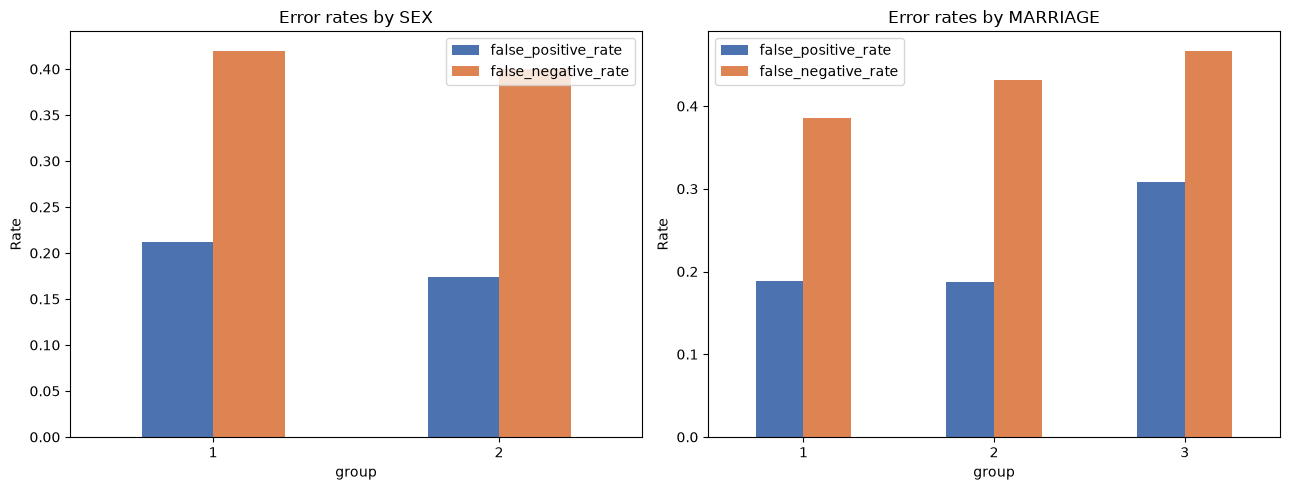

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex_report.set_index("group")[["false_positive_rate", "false_negative_rate"]].plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Error rates by SEX")
axes[0].set_ylabel("Rate")
axes[0].tick_params(axis="x", rotation=0)

marriage_report.set_index("group")[["false_positive_rate", "false_negative_rate"]].plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"]
)
axes[1].set_title("Error rates by MARRIAGE")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/fairness_error_rates.png", dpi=150)
plt.show()

## Fairness Audit

The model's error rates were compared across SEX and MARRIAGE, both flagged as
protected attributes in EDA (Stage 3) due to statistically significant association
with the target.

**SEX:** a real disparity exists. The model has a notably higher false positive rate
for male customers (21.2%) than female customers (17.4%) — male customers are more
likely to be wrongly classified as high-risk. AUC is also lower for males (0.752 vs
0.784). This gap is moderate but consistent across every metric, and would warrant
further investigation (e.g. fairness-constrained training, post-hoc threshold
adjustment per group) before any production use.

**MARRIAGE:** a similar, smaller gap exists between married and single customers.
The "others" category shows the largest disparity (FPR 30.8% vs ~19% elsewhere), but
this group is very small (n=67, ~1% of test set), so the estimate is unreliable and
should not be treated as a confirmed finding without more data.

**Conclusion:** this model should not be deployed for real lending decisions without
a dedicated fairness mitigation step. This audit demonstrates the *method* (per-group
confusion matrix breakdown) rather than delivering a bias-free model — which is itself
an honest and appropriate scope for a portfolio project.